---
## 1. Carga de datos

In [2]:
df1 = pd.read_csv('data/data.csv', encoding='latin-1', dtype=str, low_memory=False)
df2 = pd.read_csv('data/online_retail_II.csv', dtype=str, low_memory=False)
print(f'Source 1 — Filas: {len(df1):,} | Columnas: {df1.shape[1]}')
print(f'Source 2 — Filas: {len(df2):,} | Columnas: {df2.shape[1]}')
df2.head(30)

FileNotFoundError: [Errno 2] No such file or directory: 'data/data.csv'

---
## 2. Estructura de columnas y tipos de dato

In [ ]:
print('=== SOURCE 1 — Columnas y tipos ===')
print(df1.dtypes)
print()
print('=== SOURCE 2 — Columnas y tipos ===')
print(df2.dtypes)

=== SOURCE 1 — Columnas y tipos ===
InvoiceNo      str
StockCode      str
Description    str
Quantity       str
InvoiceDate    str
UnitPrice      str
CustomerID     str
Country        str
dtype: object

=== SOURCE 2 — Columnas y tipos ===
Invoice        str
StockCode      str
Description    str
Quantity       str
InvoiceDate    str
Price          str
Customer ID    str
Country        str
dtype: object


In [ ]:
print('Columnas SOURCE 1:', list(df1.columns))
print('Columnas SOURCE 2:', list(df2.columns))
print()
print('Diferencias clave:')
print('  InvoiceNo  (S1) vs Invoice     (S2)')
print('  UnitPrice  (S1) vs Price       (S2)')
print('  CustomerID (S1) vs Customer ID (S2) <- tiene espacio')
print()
print('DECISION: Renombrar columnas al esquema canonico en extract.py')

Columnas SOURCE 1: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Columnas SOURCE 2: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Diferencias clave:
  InvoiceNo  (S1) vs Invoice     (S2)
  UnitPrice  (S1) vs Price       (S2)
  CustomerID (S1) vs Customer ID (S2) <- tiene espacio

DECISION: Renombrar columnas al esquema canonico en extract.py


---
## 3. Valores nulos

In [ ]:
def reporte_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    result = pd.DataFrame({'Nulos': nulos, '% del total': pct})
    result = result[result['Nulos'] > 0]
    print(f'=== {nombre} ===')
    print(result if not result.empty else 'Sin nulos')
    print()
reporte_nulos(df1, 'Source 1')
reporte_nulos(df2, 'Source 2')

=== Source 1 ===
              Nulos  % del total
Description    1454         0.27
CustomerID   135080        24.93

=== Source 2 ===
              Nulos  % del total
Description    4382         0.41
Customer ID  243007        22.77



In [ ]:
decisiones_nulos = pd.DataFrame({
    'Campo': ['CustomerID / Customer ID', 'Description'],
    'Problema': ['~25% sin cliente', 'Algunos sin descripcion'],
    'Decision': ['TRATAR — Asignar ANONYMOUS', 'TRATAR — Dejar vacio'],
    'Impacto': ['Incluye 25% mas ventas', 'Minimo, code es la clave']
})
decisiones_nulos

,Campo,Problema,Decision,Impacto
0,CustomerID / Customer ID,~25% sin cliente,TRATAR — Asignar ANONYMOUS,Incluye 25% mas ventas
1,Description,Algunos sin descripcion,TRATAR — Dejar vacio,"Minimo, code es la clave"


---
## 4. Quantity — Ventas vs Devoluciones

In [ ]:
df1['qty'] = pd.to_numeric(df1['Quantity'], errors='coerce')
df2['qty'] = pd.to_numeric(df2['Quantity'], errors='coerce')
for df, nombre in [(df1,'Source 1'), (df2,'Source 2')]:
    total  = len(df)
    ventas = (df['qty'] > 0).sum()
    devol  = (df['qty'] <= 0).sum()
    nulos  = df['qty'].isna().sum()
    print(f'=== {nombre} ===')
    print(f'  Ventas  (qty>0):  {ventas:,} ({ventas/total*100:.1f}%)')
    print(f'  Devol   (qty<=0): {devol:,}  ({devol/total*100:.1f}%)')
    print(f'  No convertibles:  {nulos:,}')
    print(f'  Min: {df["qty"].min():.0f} | Max: {df["qty"].max():.0f}')
    print()

=== Source 1 ===
  Ventas  (qty>0):  531,285 (98.0%)
  Devol   (qty<=0): 10,624  (2.0%)
  No convertibles:  0
  Min: -80995 | Max: 80995

=== Source 2 ===
  Ventas  (qty>0):  1,044,421 (97.8%)
  Devol   (qty<=0): 22,950  (2.2%)
  No convertibles:  0
  Min: -80995 | Max: 80995



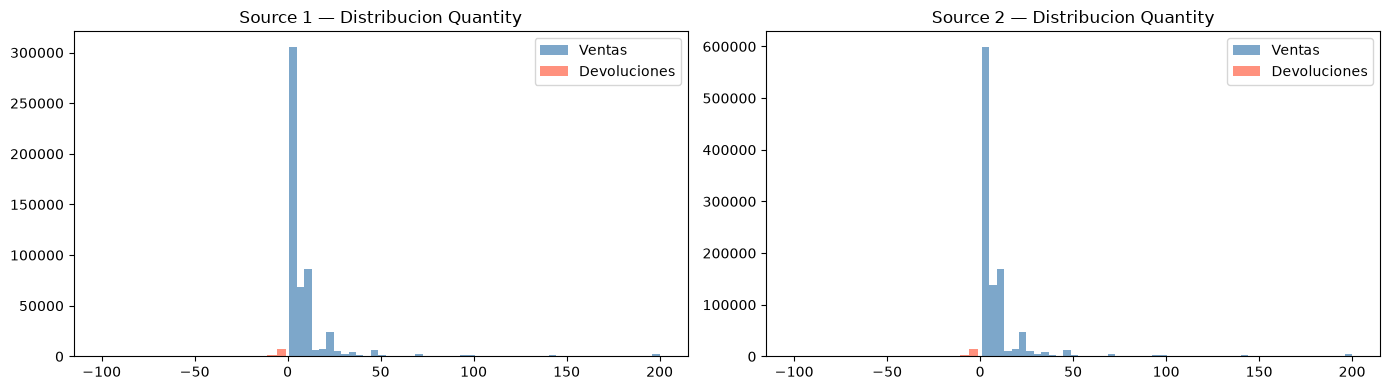

DECISION: qty<=0 -> RETURN | qty no numerico -> RECHAZAR a log_rejected_records


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, nombre in zip(axes, [df1, df2], ['Source 1', 'Source 2']):
    data = df['qty'].dropna().clip(-100, 200)
    ax.hist(data[data > 0],  bins=50, color='steelblue', alpha=0.7, label='Ventas')
    ax.hist(data[data <= 0], bins=20, color='tomato',    alpha=0.7, label='Devoluciones')
    ax.set_title(f'{nombre} — Distribucion Quantity')
    ax.legend()
plt.tight_layout()
plt.show()
print('DECISION: qty<=0 -> RETURN | qty no numerico -> RECHAZAR a log_rejected_records')

---
## 5. UnitPrice / Price

In [ ]:
df1['price'] = pd.to_numeric(df1['UnitPrice'], errors='coerce')
df2['price'] = pd.to_numeric(df2['Price'],     errors='coerce')
for df, nombre in [(df1,'Source 1'), (df2,'Source 2')]:
    print(f'=== {nombre} ===')
    print(f'  Precio = 0:   {(df["price"]==0).sum():,}')
    print(f'  Precio < 0:   {(df["price"]< 0).sum():,}')
    print(f'  Precio nulo:  {df["price"].isna().sum():,}')
    print(f'  Min: {df["price"].min():.4f} | Max: {df["price"].max():.2f} | Media: {df["price"].mean():.2f}')
    print()

=== Source 1 ===
  Precio = 0:   2,515
  Precio < 0:   2
  Precio nulo:  0
  Min: -11062.0600 | Max: 38970.00 | Media: 4.61

=== Source 2 ===
  Precio = 0:   6,202
  Precio < 0:   5
  Precio nulo:  0
  Min: -53594.3600 | Max: 38970.00 | Media: 4.65



In [ ]:
print('Ejemplos con UnitPrice = 0:')
df1[df1['price']==0][['InvoiceNo','StockCode','Description','Quantity','UnitPrice']].head(5)

Ejemplos con UnitPrice = 0:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0
1970,536545,21134,NaN,1,0
1971,536546,22145,NaN,1,0
1972,536547,37509,NaN,1,0
1987,536549,85226A,NaN,1,0


In [ ]:
pd.DataFrame({
    'Problema': ['UnitPrice=0 en VENTA','UnitPrice<0','No convertible'],
    'Decision': ['RECHAZAR','RECHAZAR','RECHAZAR'],
    'Destino':  ['log_rejected_records']*3,
    'Razon':    ['Sin valor analitico','Error de sistema','Dato corrupto']
})

,Problema,Decision,Destino,Razon
0,UnitPrice=0 en VENTA,RECHAZAR,log_rejected_records,Sin valor analitico
1,UnitPrice<0,RECHAZAR,log_rejected_records,Error de sistema
2,No convertible,RECHAZAR,log_rejected_records,Dato corrupto


---
## 6. Fechas

In [ ]:
df1['fecha'] = pd.to_datetime(df1['InvoiceDate'], errors='coerce')
df2['fecha'] = pd.to_datetime(df2['InvoiceDate'], errors='coerce')
for df, nombre in [(df1,'Source 1'),(df2,'Source 2')]:
    print(f'=== {nombre} ===')
    print(f'  Formato: {df["InvoiceDate"].iloc[0]}')
    print(f'  Desde:   {df["fecha"].min()}')
    print(f'  Hasta:   {df["fecha"].max()}')
    print(f'  Invalidas: {df["fecha"].isna().sum():,}')
    print()
print(f'Solapamiento: S1 termina {df1["fecha"].max().date()} | S2 empieza {df2["fecha"].min().date()}')
print('DECISION: Fechas invalidas -> RECHAZAR | Validas -> convertir a UTC')

=== Source 1 ===
  Formato: 12/1/2010 8:26
  Desde:   2010-12-01 08:26:00
  Hasta:   2011-12-09 12:50:00
  Invalidas: 0

=== Source 2 ===
  Formato: 2009-12-01 07:45:00
  Desde:   2009-12-01 07:45:00
  Hasta:   2011-12-09 12:50:00
  Invalidas: 0

Solapamiento: S1 termina 2011-12-09 | S2 empieza 2009-12-01
DECISION: Fechas invalidas -> RECHAZAR | Validas -> convertir a UTC


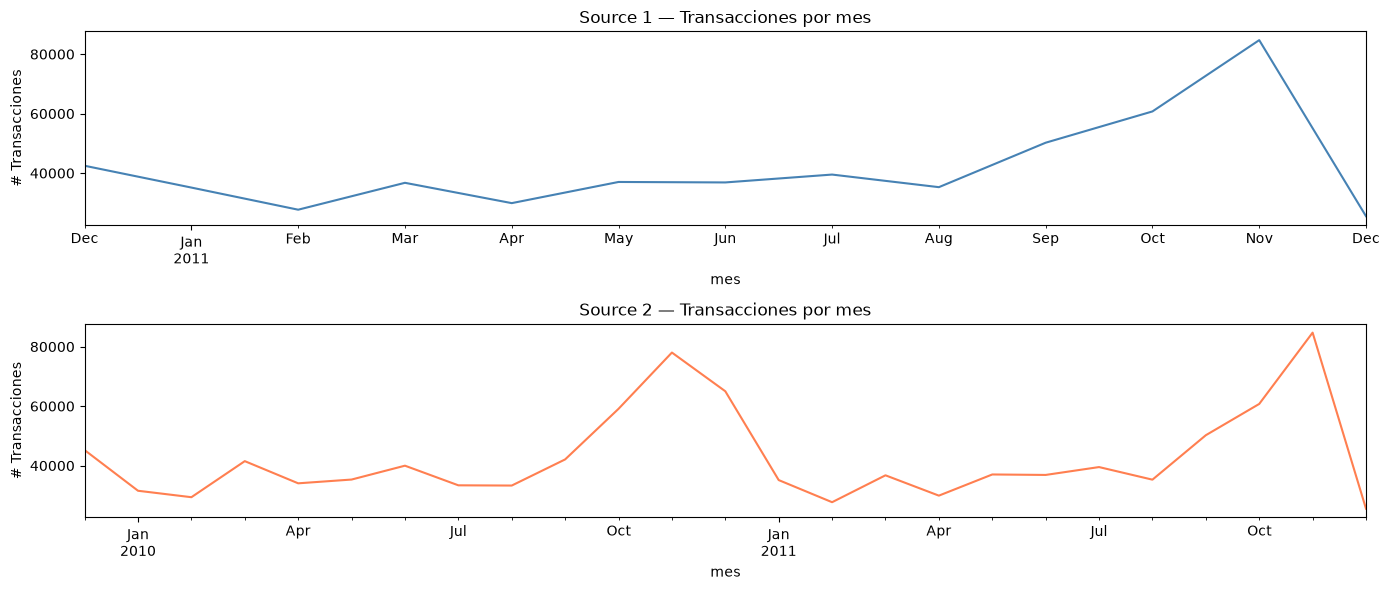

In [ ]:
df1['mes'] = df1['fecha'].dt.to_period('M')
df2['mes'] = df2['fecha'].dt.to_period('M')
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
df1.groupby('mes').size().plot(ax=axes[0], color='steelblue', title='Source 1 — Transacciones por mes')
df2.groupby('mes').size().plot(ax=axes[1], color='coral',     title='Source 2 — Transacciones por mes')
for ax in axes:
    ax.set_ylabel('# Transacciones')
plt.tight_layout()
plt.show()

---
## 7. CustomerID

In [ ]:
sin1 = df1['CustomerID'].isnull().sum()
sin2 = df2['Customer ID'].isnull().sum()
print(f'Source 1 sin CustomerID:  {sin1:,} ({sin1/len(df1)*100:.1f}%)')
print(f'Source 2 sin Customer ID: {sin2:,} ({sin2/len(df2)*100:.1f}%)')
print(f'Clientes unicos S1: {df1["CustomerID"].nunique():,}')
print(f'Clientes unicos S2: {df2["Customer ID"].nunique():,}')
print()
print('DECISION: TRATAR -> ID = ANONYMOUS')
print('RAZON: Excluirlos sessgaria el 25% del volumen de ventas')
print('CONTROL: flag is_anonymous=True en dim_customers permite filtrarlos')

Source 1 sin CustomerID:  135,080 (24.9%)
Source 2 sin Customer ID: 243,007 (22.8%)
Clientes unicos S1: 4,372
Clientes unicos S2: 5,942

DECISION: TRATAR -> ID = ANONYMOUS
RAZON: Excluirlos sessgaria el 25% del volumen de ventas
CONTROL: flag is_anonymous=True en dim_customers permite filtrarlos


---
## 8. ProductCode — Inconsistencias

In [ ]:
desc_var = (
    df1.groupby('StockCode')['Description']
    .nunique().reset_index()
    .rename(columns={'Description':'variaciones'})
    .sort_values('variaciones', ascending=False)
)
print(f'Productos unicos S1: {df1["StockCode"].nunique():,}')
print(f'Con >1 descripcion:  {(desc_var["variaciones"]>1).sum():,}')
print()
print('Top 5 con mas variaciones:')
print(desc_var.head())
print()
print('DECISION: CORREGIR -> nombre canonico = moda (descripcion mas frecuente por codigo)')

Productos unicos S1: 4,070
Con >1 descripcion:  650

Top 5 con mas variaciones:
     StockCode  variaciones
173      20713            8
1982     23084            7
3593     85175            6
871      21830            6
429      21181            5

DECISION: CORREGIR -> nombre canonico = moda (descripcion mas frecuente por codigo)


In [ ]:
codigo = desc_var.iloc[0]['StockCode']
variaciones = df1[df1['StockCode']==codigo]['Description'].value_counts()
print(f'Variaciones para {codigo}:')
print(variaciones.head(8))
print(f'\nNombre canonico: "{variaciones.index[0]}" ({variaciones.iloc[0]} ocurrencias)')

Variaciones para 20713:
Description
JUMBO BAG OWLS                  673
wrongly marked. 23343 in box      1
wrongly coded-23343               1
found                             1
Found                             1
wrongly marked 23343              1
Marked as 23343                   1
wrongly coded 23343               1
Name: count, dtype: int64

Nombre canonico: "JUMBO BAG OWLS" (673 ocurrencias)


In [ ]:
patron_letras = ~df1['StockCode'].str.match(r'^\d+', na=False)
print(f'Codigos con letras al inicio: {patron_letras.sum():,}')
print('Ejemplos:', df1[patron_letras]['StockCode'].unique()[:10])
print()
print('DECISION: TRATAR -> incluir, normalizar a MAYUSCULAS sin espacios')

Codigos con letras al inicio: 2,995
Ejemplos: <StringArray>
[        'POST',            'D',           'C2',          'DOT',
            'M', 'BANK CHARGES',            'S',    'AMAZONFEE',
     'DCGS0076',     'DCGS0003']
Length: 10, dtype: str

DECISION: TRATAR -> incluir, normalizar a MAYUSCULAS sin espacios


---
## 9. Duplicados

In [ ]:
dup1 = df1.duplicated(subset=['InvoiceNo','StockCode','Quantity','InvoiceDate']).sum()
dup2 = df2.duplicated(subset=['Invoice','StockCode','Quantity','InvoiceDate']).sum()
print(f'Duplicados internos Source 1: {dup1:,}')
print(f'Duplicados internos Source 2: {dup2:,}')
solapados = set(df1['InvoiceNo'].dropna()) & set(df2['Invoice'].dropna())
print(f'Facturas solapadas entre fuentes: {len(solapados):,}')
print()
print('DECISION: Source 2 PRIORIDAD en conflictos entre fuentes')
print('MECANISMO: concat(S2, S1) + drop_duplicates(keep=first)')

Duplicados internos Source 1: 5,429
Duplicados internos Source 2: 34,604
Facturas solapadas entre fuentes: 25,900

DECISION: Source 2 PRIORIDAD en conflictos entre fuentes
MECANISMO: concat(S2, S1) + drop_duplicates(keep=first)


---
## 10. Paises — Distribucion

Paises unicos: 38


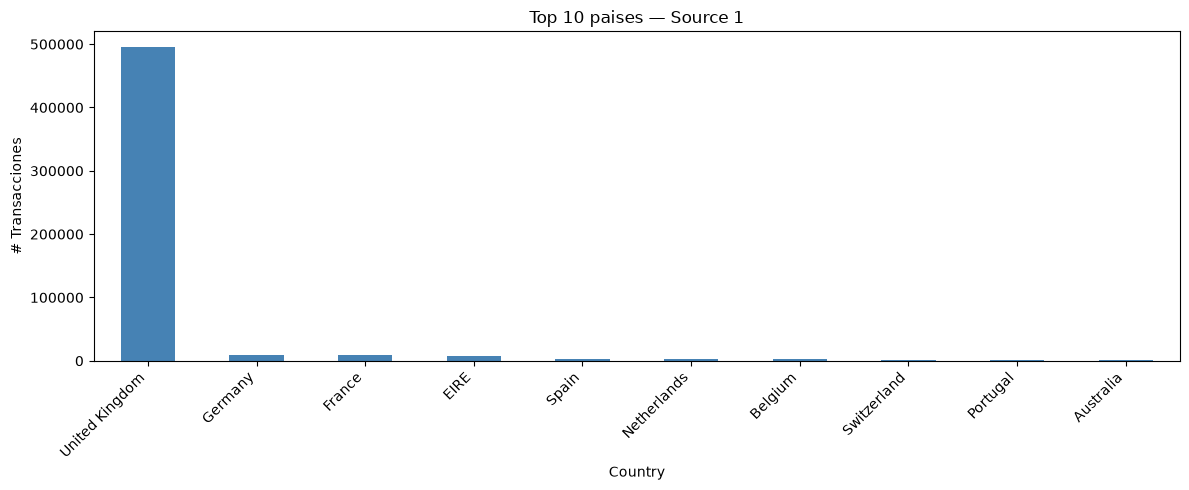

In [ ]:
paises = df1['Country'].value_counts()
print(f'Paises unicos: {df1["Country"].nunique()}')
fig, ax = plt.subplots(figsize=(12,5))
paises.head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 paises — Source 1')
ax.set_ylabel('# Transacciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 11. Resumen final de decisiones

In [ ]:
resumen = pd.DataFrame({
    'Problema': [
        'CustomerID nulo','Quantity<=0','Quantity no numerico',
        'UnitPrice=0 en venta','UnitPrice<0','UnitPrice no numerico',
        'Fecha invalida','Descripcion inconsistente',
        'Codigo con letras','Duplicados entre fuentes','Duplicados internos'
    ],
    'Accion': [
        'TRATAR','TRATAR','RECHAZAR',
        'RECHAZAR','RECHAZAR','RECHAZAR',
        'RECHAZAR','CORREGIR',
        'TRATAR','TRATAR','ELIMINAR'
    ],
    'Detalle': [
        'ID = ANONYMOUS','Marcar como RETURN','log_rejected_records',
        'log_rejected_records','log_rejected_records','log_rejected_records',
        'log_rejected_records','Moda como nombre canonico',
        'Incluir, normalizar mayusculas','Source 2 tiene prioridad','drop_duplicates'
    ]
})

def color_accion(val):
    c = {'RECHAZAR':'background-color:#ffcccc','CORREGIR':'background-color:#fff3cd',
         'TRATAR':'background-color:#d4edda','ELIMINAR':'background-color:#cce5ff'}
    return c.get(val,'')

print(resumen.to_string(index=False))

                 Problema   Accion                        Detalle
          CustomerID nulo   TRATAR                 ID = ANONYMOUS
              Quantity<=0   TRATAR             Marcar como RETURN
     Quantity no numerico RECHAZAR           log_rejected_records
     UnitPrice=0 en venta RECHAZAR           log_rejected_records
              UnitPrice<0 RECHAZAR           log_rejected_records
    UnitPrice no numerico RECHAZAR           log_rejected_records
           Fecha invalida RECHAZAR           log_rejected_records
Descripcion inconsistente CORREGIR      Moda como nombre canonico
        Codigo con letras   TRATAR Incluir, normalizar mayusculas
 Duplicados entre fuentes   TRATAR       Source 2 tiene prioridad
      Duplicados internos ELIMINAR                drop_duplicates
